# 03 · Learning: which sensors does a network need?

`run.py train`: a small U-Net per input set (`R`, `C`, `P`, `CP`, `RC`, `RP`, `RCP`) and
target (the future radar, or the future radar adjusted with links and PWS), and a hybrid
that corrects the pysteps extrapolation. Trained on the training weeks, stopped on the
validation weeks, scored on the test weeks at the physics issue times.

In [1]:
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")       # torch + pysteps in one process (macOS)
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
ROOT = Path.cwd().resolve()
while not (ROOT / "core").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "projects" / "multisensor_nowcasting" / "src"))
RES = ROOT / "projects" / "multisensor_nowcasting" / "results"
from multisensor_nowcasting.settings import NETWORKS
from multisensor_nowcasting.cube import Cube
from multisensor_nowcasting.report import label
NETS = [n for n in NETWORKS if Cube.exists(n)]
plt.rcParams.update({"figure.dpi": 72, "axes.titlesize": 10})
pd.set_option("display.precision", 3)
pd.set_option("display.width", 160)
NETS = [n for n in NETS if (RES / f"scores_{n}.csv").exists()]
print("networks with results:", NETS)

networks with results: ['openmrg', 'openmesh']


Gothenburg (OpenMRG + OpenMRG2), JJA 2015
              name  n_train  n_val  c_in  n_weights  epochs  best_val  seconds variant  chosen
0       in-R>tgt-R     2302    884    12     119164       8     0.208      474   plain   False
1       in-R>tgt-R     2302    884    12     119164      25     0.196     1502     aug    True
2       in-C>tgt-R     2302    884    13     119308      14     0.275      836   plain   False
3       in-C>tgt-R     2302    884    13     119308      11     0.271      650     aug    True
4       in-P>tgt-R     2302    884    13     119308       9     0.298      537   plain   False
5       in-P>tgt-R     2302    884    13     119308       7     0.289      412     aug    True
6      in-CP>tgt-R     2302    884    26     121180      13     0.271      827   plain    True
7      in-CP>tgt-R     2302    884    26     121180      11     0.274      699     aug   False
8      in-RC>tgt-R     2302    884    25     121036      15     0.207      997   plain    True
9      i

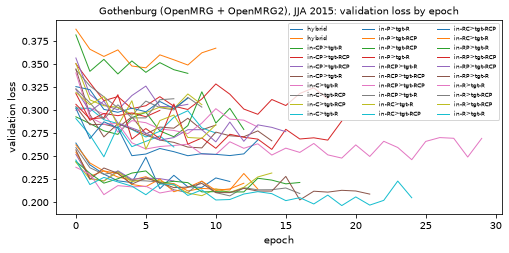

New York City (OpenMesh), Nov 2023 - Jun 2024, rain events
              name  n_train  n_val  c_in  n_weights  epochs  best_val  seconds variant  chosen
0       in-R>tgt-R     1796    540    12     119164      22     0.558     3576     aug    True
1       in-C>tgt-R     1796    540    13     119308       9     1.386     1860     aug    True
2       in-P>tgt-R     1796    540    13     119308      14     1.375     2566     aug    True
3      in-CP>tgt-R     1796    540    26     121180      12     1.344     2461     aug    True
4      in-RC>tgt-R     1796    540    25     121036      15     0.587     2148     aug    True
5      in-RP>tgt-R     1796    540    25     121036      22     0.571     3009     aug    True
6     in-RCP>tgt-R     1796    540    38     122908       9     0.674     1353     aug    True
7     in-R>tgt-RCP     1796    540    12     119164      15     0.585     1871     aug    True
8     in-C>tgt-RCP     1796    540    13     119308      18     1.352     2271     aug

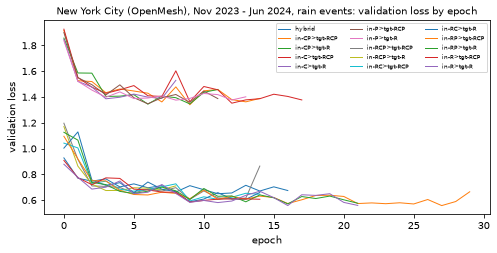

In [2]:
import json
from multisensor_nowcasting.settings import CACHE_DIR
for net in NETS:
    tr = RES / f"training_{net}.csv"
    if tr.exists():
        print(NETWORKS[net].label)
        print(pd.read_csv(tr).round(4), "\n")
    hs = [json.loads(p.read_text()) for p in sorted((CACHE_DIR / net / "learn").glob("*/history.json"))]
    if hs:
        fig, ax = plt.subplots(figsize=(8, 3.5))
        for h in hs:
            ax.plot(h["val"], lw=1, label=h["name"])
        ax.set_xlabel("epoch"); ax.set_ylabel("validation loss"); ax.legend(fontsize=6, ncol=3)
        ax.set_title(f"{NETWORKS[net].label}: validation loss by epoch")
        plt.show()

## The sensor ablation

CSI at 1 mm/h against the radar (30 and 60 min) and the next-hour total at the gauges, for
every model, next to the radar's pysteps extrapolation.

In [3]:
for net in NETS:
    sc = pd.read_csv(RES / f"scores_{net}.csv")
    ga = pd.read_csv(RES / f"gauges_{net}.csv")
    keep = sc.forecast.str.startswith("learned") | (sc.forecast == "R|extrapolation")
    a = sc[keep & (sc.region == "domain") & sc.lead_min.isin([30, 60])].pivot_table(
        index="forecast", columns="lead_min", values="CSI_1")
    b = ga[ga.what == "next-hour total"].set_index("forecast")[["RMSE", "corr"]]
    t = a.join(b)
    t.index = [label(f) for f in t.index]
    t.columns = ["CSI 30 min", "CSI 60 min", "gauges next-hour RMSE", "gauges corr"]
    print(NETWORKS[net].label)
    print(t.round(3), "\n")

Gothenburg (OpenMRG + OpenMRG2), JJA 2015
                                                    CSI 30 min  CSI 60 min  gauges next-hour RMSE  gauges corr
R: extrapolation (own motion)                            0.474       0.346                  1.204        0.558
U-Net: correction of the radar extrapolation (i...       0.462       0.351                  1.369        0.548
U-Net: inputs C -> radar, uncalibrated                   0.230       0.140                  1.228        0.393
U-Net: inputs C -> merged RCP, uncalibrated              0.276       0.237                  1.266        0.620
U-Net: inputs CP -> radar, uncalibrated                  0.255       0.175                  1.195        0.500
U-Net: inputs CP -> merged RCP, uncalibrated             0.289       0.236                  1.074        0.634
U-Net: inputs P -> radar, uncalibrated                   0.244       0.147                  1.142        0.531
U-Net: inputs P -> merged RCP, uncalibrated              0.277       0

## One test forecast, by eye

The wettest issue time of the test weeks: the observed radar, the pysteps extrapolation and
three models at 30 and 60 minutes.

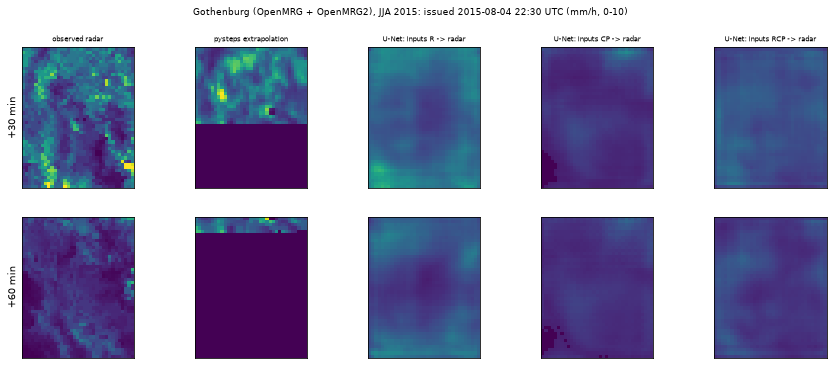

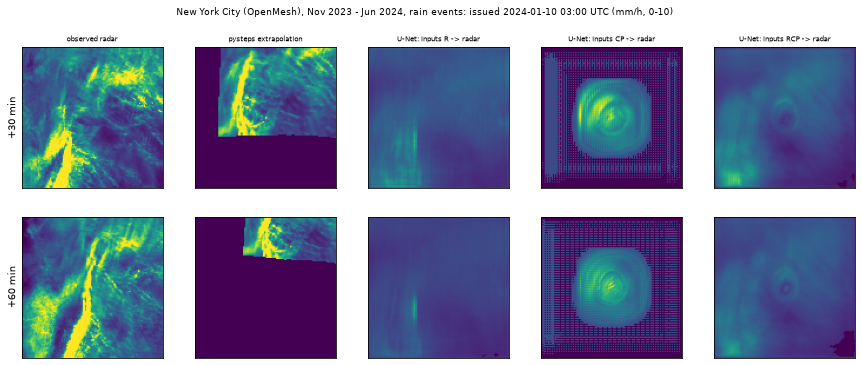

In [4]:
from core.nowcast import methods as M
from core.nowcast.grid import metadata
from multisensor_nowcasting import learn
from multisensor_nowcasting.physics import load_issues
for net in NETS:
    c = Cube(net)
    iss = load_issues(net)
    idx = iss["idx"].astype(int)
    k = int(idx[np.argmax([np.nanmean(np.asarray(c["R"][i]) > 1) for i in idx])])
    meta = metadata(c.grid, 5)
    hist = np.nan_to_num(np.asarray(c["R"][k - 5:k + 1], dtype=float))
    ext = M.deterministic("extrapolation", hist, meta, M.motion(hist, meta, "LK"), 12)
    rows = [("observed radar", np.asarray(c["R"][k + 1:k + 13])), ("pysteps extrapolation", ext)]
    for name in ["in-R>tgt-R", "in-CP>tgt-R", "in-RCP>tgt-R"]:
        try:
            rows.append((label(f"learned|{name}"), learn.predict(net, name, np.array([k]))[0]))
        except Exception as exc:
            print(name, "not available:", exc)
    fig, axes = plt.subplots(2, len(rows), figsize=(3 * len(rows), 5.6))
    for j, (name, f) in enumerate(rows):
        for r, li in enumerate((5, 11)):
            ax = axes[r, j]
            ax.imshow(np.ma.masked_invalid(f[li]), origin="lower", cmap="viridis", vmin=0, vmax=10)
            ax.set_xticks([]); ax.set_yticks([])
            if r == 0:
                ax.set_title(name, fontsize=7)
        axes[0, 0].set_ylabel("+30 min"); axes[1, 0].set_ylabel("+60 min")
    fig.suptitle(f"{NETWORKS[net].label}: issued {c.times[k]:%Y-%m-%d %H:%M} UTC (mm/h, 0-10)", fontsize=9)
    plt.show()